# Image Explanations with shapiq

This notebook demonstrates how to use `shapiq` and `shapiq_games` to explain image classifiers with Shapley values and higher-order interaction indices.

## Sections
1. Setup & imports
2. ViT with patch-based players (9 and 16 patches)
3. ResNet-18 with SLIC superpixel players
4. Higher-order interactions: k-SII between patches
5. Masking strategy comparison (patch mean vs attention masking)
6. Edge-case: low-confidence / ambiguous image

In [2]:
import tempfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

import shapiq
from shapiq_games.benchmark import ImageClassifierLocalXAI


## 1. Loading Image

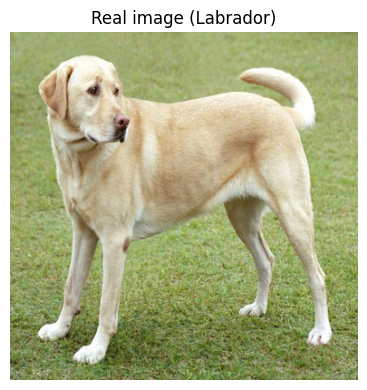

In [9]:
from PIL import Image
import numpy as np

# Load a real photo saved locally in the data/ folder
IMG_ARR = np.array(
    Image.open("../../data/demo_dog.jpg").convert("RGB").resize((384, 384))
)
IMG_PATH = save_temp_image(IMG_ARR)
show_image(IMG_ARR, "Real image (Labrador)")


## 2. ViT — Patch-Based Players

The ViT model is queried by masking entire patches via the `bool_masked_pos` parameter in the HuggingFace embedding layer — **no pixel-level replacement needed**. This is the cleanest form of image imputation.

We use 9 patches (3×3 grid) for speed; 16 patches gives finer granularity.

In [10]:
# ── 2a. 9-patch ViT ──────────────────────────────────────────────────────────
game_vit9 = ImageClassifierLocalXAI(
    model_name='vit_9_patches',
    x_explain_path=IMG_PATH,
    normalize=True,
)
print(f'Players (patches): {game_vit9.n_players}')
print(f'Grand-coalition value: {game_vit9.grand_coalition_value:.4f}')

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Players (patches): 9
Grand-coalition value: 0.9834


In [11]:
# ── 2b. Compute Shapley Values with KernelSHAP ───────────────────────────────
ks = shapiq.KernelSHAP(n=game_vit9.n_players, random_state=0)
sv_vit9 = ks.approximate(budget=200, game=game_vit9)
print(sv_vit9)

InteractionValues(
    index=SV, max_order=1, min_order=0, estimated=True, estimation_budget=200,
    n_players=9, baseline_value=0.0,
    Top 10 interactions:
        (0,): 0.5195565767317604
        (4,): 0.16631278785762205
        (1,): 0.14052147947231852
        (5,): 0.0898005170116161
        (2,): 0.07274473033951856
        (3,): 0.036135062868048386
        (7,): 0.0021941704017491457
        (8,): 0.00033406342761439344
        (): 0.0
        (6,): -0.044229878894827865
)


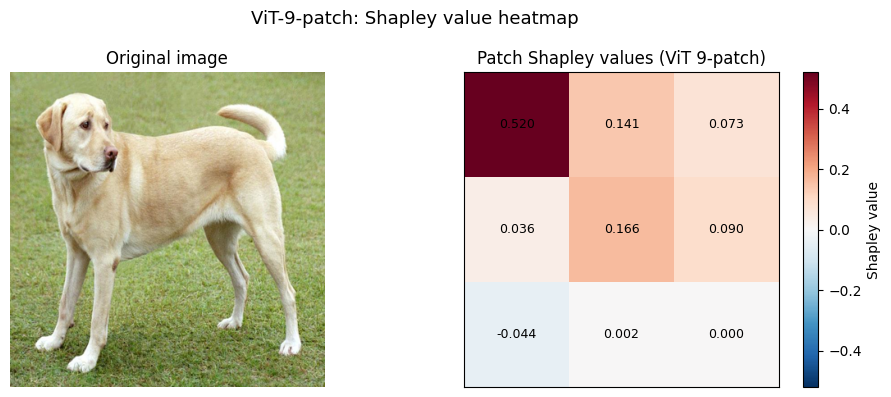

In [12]:
# ── 2c. Visualise as a 3×3 heatmap overlaid on the image ─────────────────────
patch_svs = np.array([sv_vit9[(i,)] for i in range(9)])  # order: top-left → bottom-right
grid = patch_svs.reshape(3, 3)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(IMG_ARR)
axes[0].set_title('Original image')
axes[0].axis('off')

im = axes[1].imshow(grid, cmap='RdBu_r', vmin=-abs(grid).max(), vmax=abs(grid).max())
plt.colorbar(im, ax=axes[1], label='Shapley value')
axes[1].set_title('Patch Shapley values (ViT 9-patch)')
axes[1].set_xticks([]); axes[1].set_yticks([])

# annotate cells
for r in range(3):
    for c in range(3):
        axes[1].text(c, r, f'{grid[r,c]:.3f}', ha='center', va='center', fontsize=9)

plt.suptitle('ViT-9-patch: Shapley value heatmap', fontsize=13)
plt.tight_layout()
plt.show()

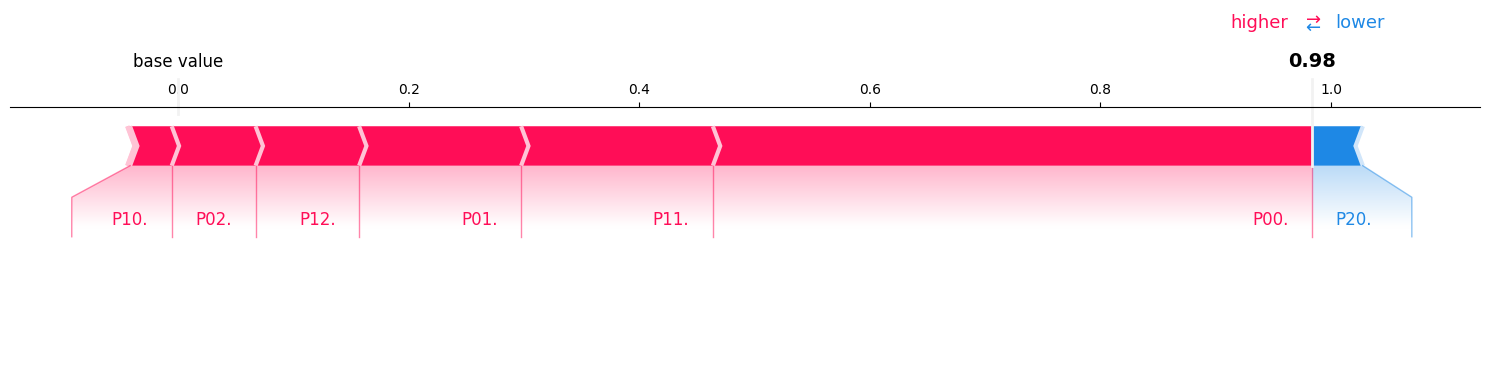

In [18]:
# ── 2d. Force plot ───────────────────────────────────────────────────────────
patch_names = [f'P{r}{c}' for r in range(3) for c in range(3)]
sv_vit9.plot_force(feature_names=patch_names)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

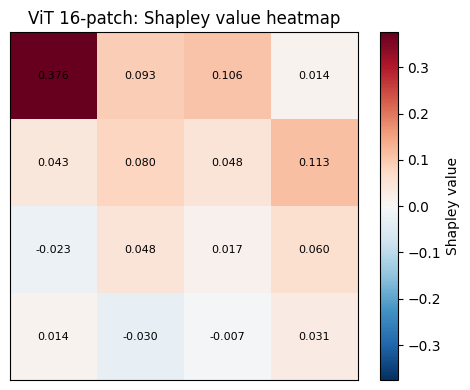

In [14]:
# ── 2e. Finer grid: 16-patch ViT ─────────────────────────────────────────────
game_vit16 = ImageClassifierLocalXAI(
    model_name='vit_16_patches',
    x_explain_path=IMG_PATH,
    normalize=True,
)
ks16 = shapiq.KernelSHAP(n=game_vit16.n_players, random_state=0)
sv_vit16 = ks16.approximate(budget=512, game=game_vit16)

grid16 = np.array([sv_vit16[(i,)] for i in range(16)]).reshape(4, 4)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(grid16, cmap='RdBu_r', vmin=-abs(grid16).max(), vmax=abs(grid16).max())
plt.colorbar(im, ax=ax, label='Shapley value')
ax.set_title('ViT 16-patch: Shapley value heatmap')
ax.set_xticks([]); ax.set_yticks([])
for r in range(4):
    for c in range(4):
        ax.text(c, r, f'{grid16[r,c]:.3f}', ha='center', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## 3. ResNet-18 — SLIC Superpixel Players

For CNNs there is no clean attention-masking path. Instead, each superpixel is replaced with the **mean colour** of the image when it is not in the coalition. This is the current approach in `_resnet_setup.py`.

In [15]:
game_resnet = ImageClassifierLocalXAI(
    model_name='resnet_18',
    n_superpixel_resnet=9,   # target ~9 superpixels
    x_explain_path=IMG_PATH,
    normalize=True,
)
n_sp = game_resnet.n_players
print(f'Superpixels found: {n_sp}')
print(f'Grand-coalition value: {game_resnet.grand_coalition_value:.4f}')

Superpixels found: 9
Grand-coalition value: 0.7010


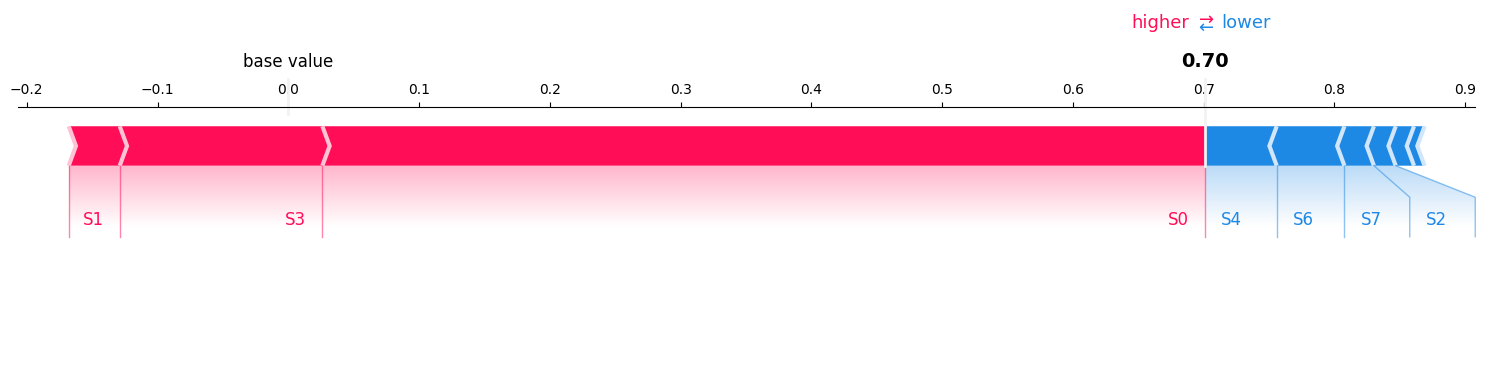

In [16]:
ks_rn = shapiq.KernelSHAP(n=n_sp, random_state=0)
sv_resnet = ks_rn.approximate(budget=300, game=game_resnet)

sp_names = [f'SP-{i}' for i in range(n_sp)]
sv_resnet.plot_force(feature_names=sp_names)

## 4. Higher-Order Interactions: k-SII

Shapley values tell us *how much* each patch contributes in isolation. **k-SII** (k-Shapley Interaction Index) reveals *which pairs (or triples) of patches interact synergistically or antagonistically* — something first-order attributions miss entirely.

> **Key insight:** A pair of patches can each have a small individual Shapley value, yet a large positive k-SII — meaning their combined presence is much more informative than the sum of their individual contributions.

In [19]:
# Use 9-patch ViT game (small enough for meaningful interaction budget)
approx_ksii = shapiq.KernelSHAPIQ(
    n=game_vit9.n_players,
    index='k-SII',
    max_order=2,
    random_state=0,
)
ksii = approx_ksii.approximate(budget=300, game=game_vit9)
print(ksii)

InteractionValues(
    index=k-SII, max_order=2, min_order=0, estimated=True, estimation_budget=300,
    n_players=9, baseline_value=0.0,
    Top 10 interactions:
        (0,): 0.9921503710310727
        (4,): 0.2262236274679404
        (1,): 0.19583387495767465
        (1, 5): 0.11386899778973816
        (2, 5): 0.10572388481689246
        (0, 6): 0.09610509178553753
        (0, 5): -0.128876296333272
        (0, 2): -0.19163099010985318
        (0, 1): -0.24774494184008006
        (0, 4): -0.25389257912080493
)


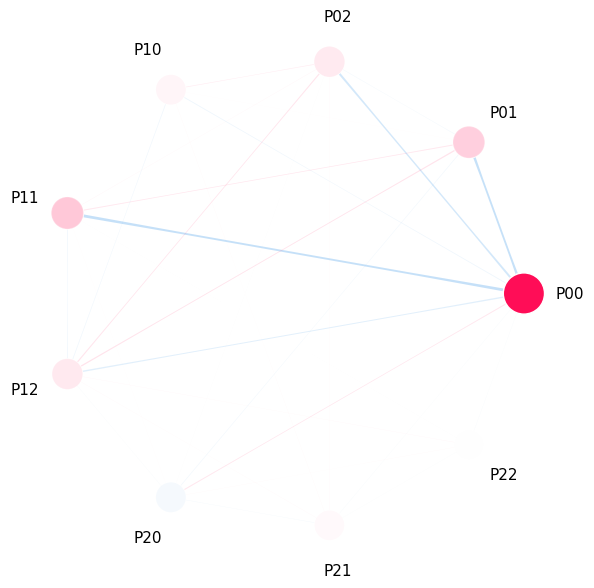

In [20]:
# Network plot: nodes = patches, edges = pairwise interactions
ksii.plot_network(feature_names=patch_names)

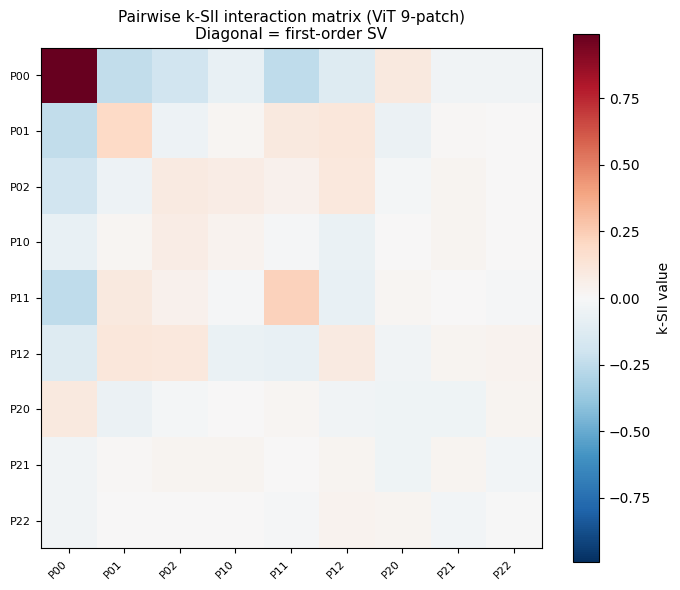

Top-3 pairwise interactions:
  P00 ↔ P11: -0.2539
  P00 ↔ P01: -0.2477
  P00 ↔ P02: -0.1916


In [25]:
# ── 4b. Manual interaction heatmap ───────────────────────────────────────────
# Show all pairwise k-SII values as a 9x9 matrix
n = game_vit9.n_players
interaction_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        if i == j:
            interaction_matrix[i, j] = ksii[(i,)]   # first-order on diagonal
        elif i < j:
            try:
                val = ksii[(i, j)]  # pairwise
                interaction_matrix[i, j] = val
                interaction_matrix[j, i] = val
            except (KeyError, IndexError):
                val = 0.0

fig, ax = plt.subplots(figsize=(7, 6))
vmax = np.abs(interaction_matrix).max()
im = ax.imshow(interaction_matrix, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
plt.colorbar(im, ax=ax, label='k-SII value')
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(patch_names, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(patch_names, fontsize=8)
ax.set_title('Pairwise k-SII interaction matrix (ViT 9-patch)\nDiagonal = first-order SV', fontsize=11)
plt.tight_layout()
plt.show()

# Report strongest pair
upper = [(i,j, interaction_matrix[i,j]) for i in range(n) for j in range(i+1, n)]
upper.sort(key=lambda x: abs(x[2]), reverse=True)
print('Top-3 pairwise interactions:')
for i, j, v in upper[:3]:
    print(f'  {patch_names[i]} ↔ {patch_names[j]}: {v:+.4f}')

## 5. Masking Strategy Comparison

A core design question is **what to put in a masked-out region**. Here we compare game values under attention masking (zero mask token — the ViT path) vs. a hypothetical mean-color replacement for the same ViT, to show how the imputation choice changes the explanation.

Since the ResNet setup uses mean-color and the ViT uses attention masking, we can compare the grand-coalition values and the Shapley value distributions side-by-side.

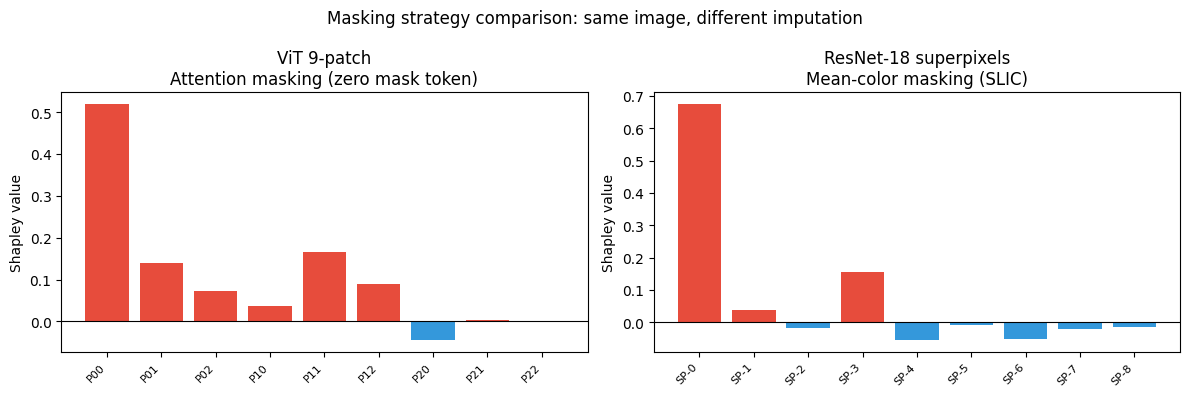

ViT grand-coalition value:    0.9834
ResNet grand-coalition value: 0.7010

Note: different scales because the models output different class probabilities.


In [22]:
# Side-by-side comparison: ViT (attention mask) vs ResNet (mean-color SLIC)
# We align both on 9 players for comparability.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ViT SVs
vit_svs = [sv_vit9[(i,)] for i in range(9)]
axes[0].bar(range(9), vit_svs, color=['#e74c3c' if v > 0 else '#3498db' for v in vit_svs])
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_xticks(range(9))
axes[0].set_xticklabels(patch_names, rotation=45, ha='right', fontsize=8)
axes[0].set_title('ViT 9-patch\nAttention masking (zero mask token)')
axes[0].set_ylabel('Shapley value')

# ResNet SVs (may have different n_players; pad/truncate for visual)
rn_svs = [sv_resnet[(i,)] for i in range(n_sp)]
axes[1].bar(range(n_sp), rn_svs, color=['#e74c3c' if v > 0 else '#3498db' for v in rn_svs])
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticks(range(n_sp))
axes[1].set_xticklabels(sp_names, rotation=45, ha='right', fontsize=8)
axes[1].set_title('ResNet-18 superpixels\nMean-color masking (SLIC)')
axes[1].set_ylabel('Shapley value')

plt.suptitle('Masking strategy comparison: same image, different imputation', fontsize=12)
plt.tight_layout()
plt.show()

print(f'ViT grand-coalition value:    {game_vit9.grand_coalition_value:.4f}')
print(f'ResNet grand-coalition value: {game_resnet.grand_coalition_value:.4f}')
print('\nNote: different scales because the models output different class probabilities.')

### Discussion: masking strategies

| Strategy | When it works well | When it fails |
|---|---|---|
| **Attention masking** (zero token) | ViT: native; no OOD pixel artefacts | CNN: not applicable; requires model access |
| **Mean-color** | Simple CNN baseline; quick to implement | Creates obvious grey blobs; can cause OOD inputs |
| **Blur** (Gaussian) | Softer transition; less OOD than mean | Leaks some texture through; slower for large images |
| **Zero / black** | Fastest; no precomputation | Most likely to be OOD; model may react to blackness itself |

## 6. Edge-Case: Low-Confidence Prediction

An honest demo includes cases where the explanation is *surprising or potentially misleading*. Here we show what happens when the model is uncertain — the Shapley values can be large in magnitude despite a low-confidence prediction, which can be misinterpreted.

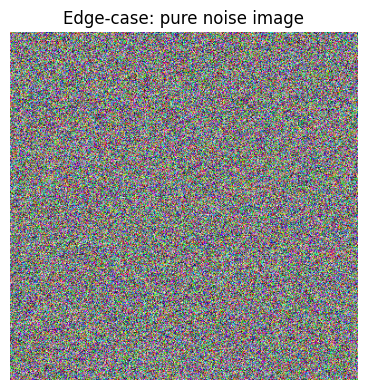

In [23]:
# Simulate an ambiguous image: pure uniform noise (model should be very uncertain)
rng = np.random.default_rng(999)
noise_arr = rng.integers(0, 255, (384, 384, 3), dtype=np.uint8)
noise_path = save_temp_image(noise_arr)
show_image(noise_arr, 'Edge-case: pure noise image')

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Grand-coalition value (noise): 0.0549
(A high value here means the model is confidently wrong; a low value is expected for noise)


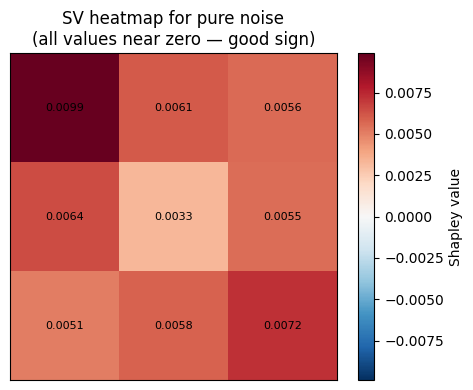


⚠️  Caution: if SVs are large despite low grand-coalition value, the explanation
    is attributing noise artefacts — not meaningful features.


In [24]:
game_noise = ImageClassifierLocalXAI(
    model_name='vit_9_patches',
    x_explain_path=noise_path,
    normalize=True,
)
print(f'Grand-coalition value (noise): {game_noise.grand_coalition_value:.4f}')
print('(A high value here means the model is confidently wrong; a low value is expected for noise)')

ks_noise = shapiq.KernelSHAP(n=game_noise.n_players, random_state=0)
sv_noise = ks_noise.approximate(budget=200, game=game_noise)

noise_svs = [sv_noise[(i,)] for i in range(9)]
grid_noise = np.array(noise_svs).reshape(3, 3)

fig, ax = plt.subplots(figsize=(5, 4))
vmax = max(abs(grid_noise).max(), 1e-6)
im = ax.imshow(grid_noise, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
plt.colorbar(im, ax=ax, label='Shapley value')
ax.set_title('SV heatmap for pure noise\n(all values near zero — good sign)')
ax.set_xticks([]); ax.set_yticks([])
for r in range(3):
    for c in range(3):
        ax.text(c, r, f'{grid_noise[r,c]:.4f}', ha='center', va='center', fontsize=8)
plt.tight_layout()
plt.show()

print('\n⚠️  Caution: if SVs are large despite low grand-coalition value, the explanation')
print('    is attributing noise artefacts — not meaningful features.')

## 7. Next Steps: What Your `ImageImputer` Should Enable

The cells above use the **hard-coded benchmark games** from `shapiq_games`. Your project will replace this with a general `ImageImputer` that plugs into the standard pipeline:

```python
# Target API (after your implementation)
from shapiq.image import ImageImputer, PatchSegmenter, MeanMasker

imputer = ImageImputer(
    model=my_model,          # any callable: pytorch, jax, timm, etc.
    image=my_image,          # PIL, numpy, or tensor
    segmenter=PatchSegmenter(grid_size=(3, 3)),
    masker=MeanMasker(),
    batch_size=32,
)

explainer = shapiq.Explainer(model=my_model, imputer=imputer)
sv = explainer.explain(my_image, budget=512)
```

Key milestones:
1. `PatchSegmenter + MeanMasker` on ViT → validate against `game_vit9` above ✓  
2. `SLICSegmenter + MeanMasker` on ResNet → validate against `game_resnet` above ✓  
3. `PatchSegmenter + BlurMasker` (new!) → compare explanations visually  
4. `PatchSegmenter + AttentionMasker` → replicate `_vit_setup.py` logic  
5. `CustomMaskSegmenter` → arbitrary user-provided binary masks  
6. JAX/Flax callable support via `TensorOps` abstraction  

## References

- Muschalik et al., *shapiq: Shapley Interactions for Machine Learning*, NeurIPS 2024
- Lundberg & Lee, *A Unified Approach to Interpreting Model Predictions*, NeurIPS 2017
- Dosovitskiy et al., *An Image is Worth 16x16 Words*, ICLR 2021
- Achanta et al., *SLIC Superpixels*, TPAMI 2012